In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [3]:
def analyze_image(path: str):
    """
    Считывает изображение, строит гистограмму яркости и печатает информацию.
    Поддерживает как уже ч/б картинки, так и цветные (конвертирует в 'L').
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {path}")

    # 1) Чтение и приведение к режиму L (0..255)
    img = Image.open(path)
    gray = img.convert("L")   # гарантированно ч/б 8-бит

    width, height = gray.size
    total_pixels = width * height

    # 2) Вектор яркостей (uint8) и гистограмма
    arr = np.array(gray, dtype=np.uint8).ravel()
    bins = np.arange(257)  # края корзин: 0..256, чтобы бины были [0,1),[1,2),...,[255,256)
    hist, _ = np.histogram(arr, bins=bins)

    # 3) Печать информации
    print(f"Файл: {path.name}")
    print(f"Разрешение: {width} × {height} пикселей")
    print(f"Количество пикселей: {total_pixels}")
    print(f"Минимальная яркость: {arr.min()}, максимальная: {arr.max()}, средняя: {arr.mean():.2f}")

    # 4) Построение гистограммы (один график, без задания цветов)
    plt.figure()
    plt.bar(range(256), hist, width=1)  # столбик на каждое значение яркости
    plt.title("Гистограмма яркости (0–255)")
    plt.xlabel("Яркость")
    plt.ylabel("Частота")
    plt.xlim(0, 255)
    plt.tight_layout()
    plt.show()

    # Возврат полезных данных, если нужно использовать дальше
    return {
        "width": width,
        "height": height,
        "total_pixels": total_pixels,
        "histogram": hist,   # длина 256, hist[i] — число пикселей с яркостью i
        "matrix": gray
    }


In [4]:
def matrix_to_image(matrix, save_path=None):
    #показываем изображение и при необходимости сохраняем

SyntaxError: incomplete input (297272093.py, line 2)

Файл: 01_apc.tif
Разрешение: 512 × 512 пикселей
Количество пикселей: 262144
Минимальная яркость: 12, максимальная: 215, средняя: 127.19


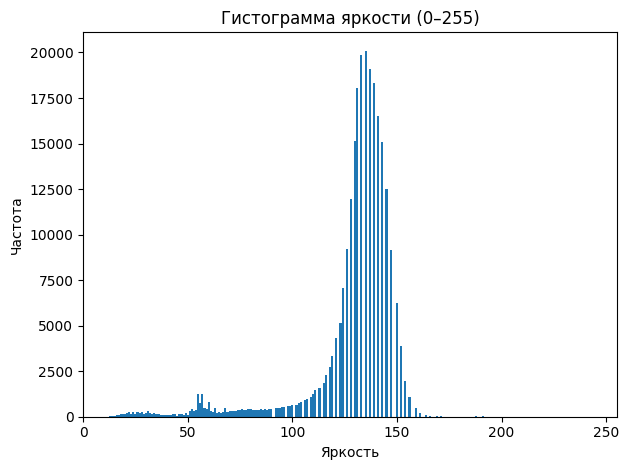

<class 'PIL.Image.Image'>


In [6]:
info = analyze_image("Тестовые изображения/01_apc.tif")
mat = info["matrix"]

print(type(mat))


In [ ]:
matrix_to_image(mat)

C:\Users\boga4\AppData\Local\Temp\ipykernel_22136\129679340.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(gray_arr, mode="L")


## 1. Пороговая обработка.

ВЫХОД:
1) Исходное изображение

2) Изображение после пороговой обработки

3) Исходная гистограмма

4) Гистограмма после пороговой обработки

5) График функции поэлементного преобразования

In [7]:
## Пороговая обработка.
def t_porog(matrix, t): 
    N = matrix.size[0]
    M = matrix.size[1]
    newMatrix = matrix
    for i in range(N):
        for j in range(M):
            if(matrix[i][j]<t):
                newMatrix[i][j] = 0
            else:
                newMatrix[i][j] = 1
    return newMatrix


## 2. Контрастирование

ВЫХОД:
1) Исходное изображение

2) Контрастированное изображение

3) Исходная гистограмма

4) Гистограмма после контрастирования

5) График функции поэлементного преобразования

In [ ]:
def contrast(matrix, gmin=0, gmax=255):
    a = gmax - gmin / (max(matrix) - min(matrix))
    b = (gmin * max(matrix) - gmax* min(matrix)) / max(matrix) - min(matrix)

    N = matrix.size[0]
    M = matrix.size[1]
    newMatrix = matrix
    for i in range(N):
        for j in range(M):
            newMatrix[i][j] = a * matrix[i][j] + b
    return newMatrix



## 3. Эквализация

1) Исходное изображение

2) Изображение после эквализации (стандратной и самописной)

3) График интегральной функции распределения яркости (до и после обработки)

4) Гистограмма исходного изображения

5) Гистограмма изображения после эквализации (стандартной и самописной)

6) График функции поэлементного преобразования

7) Выдать в консоль функцией типа print массивы гистограммы исходного изображения

и границ интервалов этой гистограммы, выданные функцией

hist, bins = histogram(...

Продемонстрировать, что массив границ интервалов bins

начинается с нуля и содержит числа 0 1 2 3 .. 255 256